# Fake News Detection Pipeline (v2)

This notebook demonstrates a streamlined pipeline for fake news detection:

1. **Data Processing**: Load raw data, clean source attribution, remove duplicates
2. **Train/Test Split**: Stratified split with configurable columns
3. **Feature Engineering**: TF-IDF vectorization
4. **Model Training**: Ridge Classifier and Logistic Regression
5. **Feature Importance**: Analyze what drives predictions

**Key improvement**: Feature and label columns are now explicitly configured and logged at each step.


In [1]:
import sys
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib

# Add project root to path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Import modules (with reload to pick up any changes)
from src.data import process_dataset, make_split
from src.features import make_features
from src.models import train_model as train_model_module

importlib.reload(make_features)
importlib.reload(train_model_module)

run_feature_engineering = make_features.run_feature_engineering
train_model = train_model_module.train_model
load_config = train_model_module.load_config

print("✓ Imports successful")


✓ Imports successful


In [2]:
# Load configuration and define paths
config = load_config(str(project_root / "config" / "config.yaml"))

# Get column configuration
FEATURE_COLUMN = config["columns"]["feature_column"]
LABEL_COLUMN = config["columns"]["label_column"]
ID_COLUMN = config["columns"]["id_column"]

print("Configuration loaded:")
print(f"  Feature column (X): '{FEATURE_COLUMN}'")
print(f"  Label column (y):   '{LABEL_COLUMN}'")
print(f"  ID column:          '{ID_COLUMN}'")


Configuration loaded:
  Feature column (X): 'text'
  Label column (y):   'label'
  ID column:          'id'


## 1. Data Processing

Load raw data, clean source attribution (e.g., "(Reuters) -"), and remove duplicates.


In [3]:
# Define paths
raw_data_path = project_root / "data" / "raw" / "WELFake_Dataset.csv"
cleaned_data_path = project_root / "data" / "processed" / "cleaned_dataset.csv"

# Process dataset: load, clean source attribution, deduplicate
df = process_dataset(
    input_path=str(raw_data_path),
    output_path=str(cleaned_data_path),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    id_column=ID_COLUMN
)


DATA PROCESSING
Input:  /Users/alanye/Fake-News-Group-3/data/raw/WELFake_Dataset.csv
Output: /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

1. Loading dataset...
   Loaded 72,134 rows
   Columns: ['id', 'title', 'text', 'label']

2. Cleaning source attribution from 'text' column...
   Removing patterns like '(Reuters) -', '(AP) -', etc.
   ✓ Source attribution removed

3. Removing duplicate articles (based on 'text')...
   Removed 27,695 duplicates
   Remaining: 44,439 unique articles

4. Label distribution ('label' column):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

5. Saving cleaned data...
✓ Saved 44439 rows to /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv

✓ DATA PROCESSING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Total rows:     44,439
  Saved to:       /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv


## 2. Train/Test Split

Create stratified train/test split (80/20) based on label column.


In [4]:
processed_dir = project_root / "data" / "processed"

train_df, test_df = make_split(
    input_path=str(cleaned_data_path),
    output_dir=str(processed_dir),
    test_size=config["models"]["test_size"],
    random_seed=config["models"]["random_seed"],
    label_column=LABEL_COLUMN,
    feature_column=FEATURE_COLUMN
)


TRAIN/TEST SPLIT

1. Loading data from /Users/alanye/Fake-News-Group-3/data/processed/cleaned_dataset.csv...
   Loaded 44,439 rows

2. Validating columns...
   Feature column (X): 'text'
   Label column (y):   'label'
   ✓ All required columns present

3. Label distribution (before split):
   0 (Real): 29,561 (66.5%)
   1 (Fake): 14,878 (33.5%)

4. Splitting data (test_size=0.2, random_seed=42)...

5. Saving splits...
   Train: /Users/alanye/Fake-News-Group-3/data/processed/train.csv (35,551 rows)
   Test:  /Users/alanye/Fake-News-Group-3/data/processed/test.csv (8,888 rows)

✓ SPLIT COMPLETE
  Feature column: 'text'
  Label column:   'label'
  Train samples:  35,551
  Test samples:   8,888


In [5]:
test_df

,id,title,text,label
4567,6728,U.S. says holds Myanmar military leaders accou...,U.S. Secretary of State Rex Tillerson said on ...,0
43904,71182,Why America might elect a president it doesn't...,Donald Trump and Hillary Clinton have among th...,0
7859,11556,N. DAKOTA LEGISLATOR Proposes Bill To PROTECT ...,Protesters who take to the streets in North Da...,1
40372,64766,"Speaker David Gowan Reshapes Arizona House, Fr...",PHOENIX — When lawmakers in the Arizona Hou...,0
4774,7036,Can The American People Defeat The Oligarchy T...,"SPECIAL TO BUSINESS WEEK, MINDY KATZMAN, AUTH....",1
...,...,...,...,...
19124,29034,“COMEDIAN” GEORGE LOPEZ Who Said About Trump S...,"When a woman in the audience objected, Lopez w...",1
10053,14931,TRUMP EXPOSES OBAMA’S INCOMPETENCE: Cuts EPA B...,Although Obama had 3 years to take action to f...,1
904,1326,Putin warns U.S. not to supply Ukraine with de...,Russian President Vladimir Putin said on Tuesd...,0
42368,68420,"UK's Johnson has ""constructive"" call with husb...",British foreign minister Boris Johnson had a ...,0


In [6]:
train_df

,id,title,text,label
1314,1921,YIKES! 30 Years Of HILLARY’S LIES Have Driven ...,This is not a fluke. After years of towing the...,1
8906,13144,The Fake News About Central Banking,The Fake News About Central Banking By Daily B...,1
30809,47995,Fact checking the fourth round of GOP debates,Fox Business News aired two GOP presidential d...,0
10085,14979,"On Campus, Trump Fans Say They Need ‘Safe Spac...","ANN ARBOR, Mich. — Amanda Delekta, a sophom...",0
30494,47478,Microsoft unveils sleek desktop computer,Microsoft unveils sleek desktop computer Re: M...,1
...,...,...,...,...
26399,40675,Puerto Rico may issue delayed audited 2014 sta...,Puerto Rico’s much-delayed audited financial s...,0
23164,35397,Merkel can well imagine a European finance min...,German Chancellor Angela Merkel said on Friday...,0
13567,20347,ATF misfire? Guide indicates bullets at center...,It looked like the fix was in. But the ATF say...,0
2279,3323,French foreign minister visits Libya in new pu...,Libya s rival factions should stick to a Unite...,0


## 3. Feature Engineering

Convert text to TF-IDF vectors (unigrams + bigrams, max 5000 features).


In [7]:
run_feature_engineering(
    processed_dir=str(processed_dir),
    feature_column=FEATURE_COLUMN,
    label_column=LABEL_COLUMN,
    max_features=config["features"]["tfidf"]["max_features"]
)


FEATURE ENGINEERING

1. Loading train/test split...

2. Extracting features and labels...
   Feature column (X): 'text'
   Label column (y):   'label'

   Train samples: 35,551
   Test samples:  8,888

   Label distribution (train):
     0 (Real): 23,649 (66.5%)
     1 (Fake): 11,902 (33.5%)

3. Creating TF-IDF features...
   Max features: 5,000
   N-gram range: (1, 2)
   ✓ Train TF-IDF shape: (35551, 5000)
   ✓ Test TF-IDF shape:  (8888, 5000)

4. Creating Word2Vec/Sentence2Vec features...
   Training Word2Vec model...
   Generating sentence vectors...
   ✓ Train W2V shape: (35551, 100)
   ✓ Test W2V shape:  (8888, 100)

5. Saving features to /Users/alanye/Fake-News-Group-3/data/processed...
   ✓ TF-IDF features saved
   ✓ Word2Vec features saved

✓ FEATURE ENGINEERING COMPLETE
  Feature column: 'text'
  Label column:   'label'
  TF-IDF shape:   (35551, 5000)
  Word2Vec shape: (35551, 100)


## 4. Model Training

Train Ridge Classifier and Logistic Regression models.


In [8]:
# Train Ridge Classifier
ridge_model, ridge_metrics, ridge_preds = train_model(
    "ridge_classifier", config, return_metrics=True,
    processed_dir=str(processed_dir),
    models_dir=str(project_root / "results" / "models")
)


MODEL TRAINING: ridge_classifier

1. Loading features and labels...
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_train_tfidf.npz
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_test_tfidf.npz

2. Data summary:
   Feature source: 'text' column → TF-IDF vectors
   Label source:   'label' column (0=Real, 1=Fake)

   X_train shape: (35551, 5000)
   X_test shape:  (8888, 5000)

   Label distribution:
     Train: 0=23649, 1=11902
     Test: 0=5912, 1=2976

3. Initializing ridge_classifier...
   Using default parameters

4. Training model...
   ✓ Training complete

5. Evaluating on test set...

   Accuracy: 0.9320

   Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.94      0.96      0.95      5912
    Fake (1)       0.91      0.88      0.90      2976

    accuracy                           0.93      8888
   macro avg       0.93      0.92      0.92      8888
weighted avg       0.93      0.93      0.93

In [9]:
# Train Logistic Regression
lr_model, lr_metrics, lr_preds = train_model(
    "logistic_regression", config, return_metrics=True,
    processed_dir=str(processed_dir),
    models_dir=str(project_root / "results" / "models")
)


MODEL TRAINING: logistic_regression

1. Loading features and labels...
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_train_tfidf.npz
   Loading: /Users/alanye/Fake-News-Group-3/data/processed/features_test_tfidf.npz

2. Data summary:
   Feature source: 'text' column → TF-IDF vectors
   Label source:   'label' column (0=Real, 1=Fake)

   X_train shape: (35551, 5000)
   X_test shape:  (8888, 5000)

   Label distribution:
     Train: 0=23649, 1=11902
     Test: 0=5912, 1=2976

3. Initializing logistic_regression...
   Parameters: {'C': 1.0, 'max_iter': 1000, 'solver': 'lbfgs'}

4. Training model...
   ✓ Training complete

5. Evaluating on test set...

   Accuracy: 0.9289

   Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.94      0.95      0.95      5912
    Fake (1)       0.90      0.88      0.89      2976

    accuracy                           0.93      8888
   macro avg       0.92      0.92      0.92      8888
we

In [10]:
import numpy as np
import pandas as pd
import joblib

# Load the training features
train_data = np.load("../data/processed/features_train_tfidf.npz", allow_pickle=True)
X_train = train_data["X"].item()  # Extract sparse matrix
y_train = train_data["y"]

print("X_train (Features):")
print(f"  Shape: {X_train.shape}")
print(f"  Type: {type(X_train)}")

print("\ny_train (Labels):")
print(f"  Shape: {y_train.shape}")
print(f"  Values: {np.unique(y_train, return_counts=True)}")

# Show sample
vectorizer = joblib.load("../data/processed/tfidf_vectorizer.pkl")
feature_names = vectorizer.get_feature_names_out()

sample_row = X_train[0].toarray().flatten()
nonzero = np.where(sample_row > 0)[0]
print(f"\nSample row 0 (label={y_train[0]}):")
print(f"  Non-zero features: {len(nonzero)}")
print(f"  Top features: {[(feature_names[i], f'{sample_row[i]:.3f}') for i in nonzero[np.argsort(sample_row[nonzero])[-5:]]]}")

X_train (Features):
  Shape: (35551, 5000)
  Type: <class 'scipy.sparse._csr.csr_matrix'>

y_train (Labels):
  Shape: (35551,)
  Values: (array([0, 1]), array([23649, 11902]))

Sample row 0 (label=1):
  Non-zero features: 16
  Top features: [('poll', '0.276'), ('bernie', '0.282'), ('bernie sanders', '0.286'), ('combined', '0.337'), ('union', '0.438')]


In [11]:
import numpy as np
import pandas as pd
import joblib

# Load the training features
train_data = np.load(str(processed_dir / "features_train_tfidf.npz"), allow_pickle=True)
X_train = train_data["X"].item()  # Extract sparse matrix
y_train = train_data["y"]

# Load vectorizer to get feature names
vectorizer = joblib.load(str(processed_dir / "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()

# Convert sparse matrix to DataFrame (first 100 rows to avoid memory issues)
n_samples = 100
X_sample = X_train[:n_samples].toarray()

df_features = pd.DataFrame(X_sample, columns=feature_names)
df_features.insert(0, 'label', y_train[:n_samples])

print(f"Shape: {df_features.shape}")
print(f"Columns: label + {len(feature_names)} TF-IDF features")
print(f"\nFirst 5 rows, first 10 columns:")
display(df_features.iloc[:5, :10])

# Show non-zero features for first sample
print(f"\nSample 0 (label={y_train[0]}) - Non-zero features:")
row = df_features.iloc[0, 1:]  # Exclude label column
nonzero = row[row > 0].sort_values(ascending=False)
print(nonzero.head(20))

Shape: (100, 5001)
Columns: label + 5000 TF-IDF features

First 5 rows, first 10 columns:


,label,000,000 people,10,10 000,10 percent,10 years,100,100 000,11
0,1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
1,1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
2,0,0.103995,0.0,0.145727,0.0,0.041099,0.0,0.013626,0.019944,0.039448
3,0,0.014065,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000
4,1,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000



Sample 0 (label=1) - Non-zero features:
union             0.438494
combined          0.337488
bernie sanders    0.286433
bernie            0.281687
poll              0.275806
sanders           0.271404
trump             0.255729
democrat          0.227359
line              0.219756
life              0.202198
members           0.188163
recent            0.186466
hillary           0.178556
support           0.166776
long              0.164246
years             0.139962
Name: 0, dtype: float64


### Model Comparison


MODEL COMPARISON

Features used: 'text' column → TF-IDF
Labels used:   'label' column (0=Real, 1=Fake)

Ridge Classifier Accuracy:    0.9320
Logistic Regression Accuracy: 0.9289


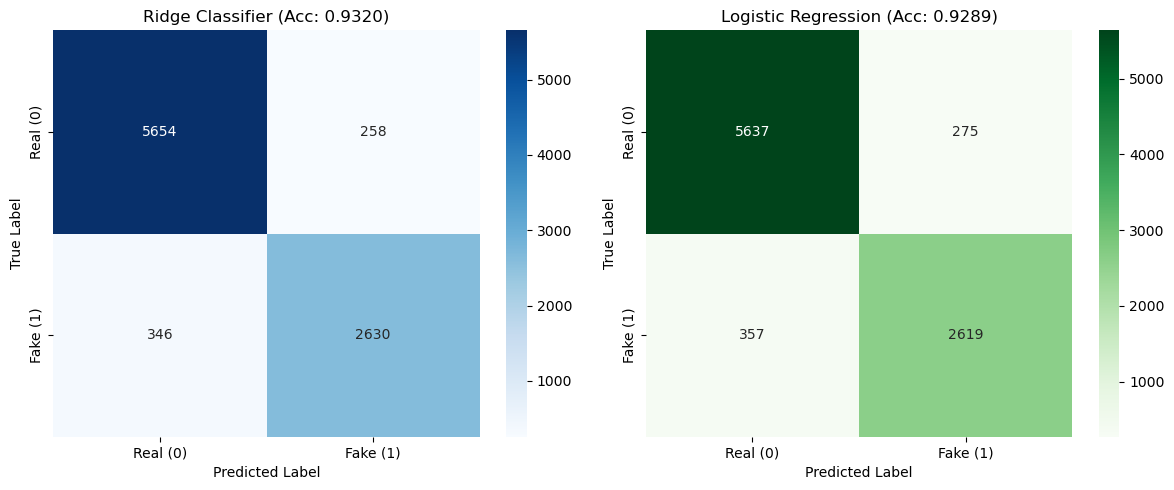

In [12]:
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"\nFeatures used: '{ridge_metrics['feature_column']}' column → TF-IDF")
print(f"Labels used:   '{ridge_metrics['label_column']}' column (0=Real, 1=Fake)")
print(f"\nRidge Classifier Accuracy:    {ridge_metrics['accuracy']:.4f}")
print(f"Logistic Regression Accuracy: {lr_metrics['accuracy']:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Ridge Confusion Matrix
sns.heatmap(ridge_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
axes[0].set_title(f"Ridge Classifier (Acc: {ridge_metrics['accuracy']:.4f})")
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Logistic Regression Confusion Matrix
sns.heatmap(lr_metrics['confusion_matrix'], annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Real (0)', 'Fake (1)'], yticklabels=['Real (0)', 'Fake (1)'])
axes[1].set_title(f"Logistic Regression (Acc: {lr_metrics['accuracy']:.4f})")
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


## 5. Feature Importance Analysis

Analyze which words/n-grams are most predictive of fake vs real news.


In [13]:
import joblib

# Load the TF-IDF vectorizer to get feature names
vectorizer = joblib.load(str(processed_dir / "tfidf_vectorizer.pkl"))
feature_names = vectorizer.get_feature_names_out()

def get_top_features(model, feature_names, n=20):
    """Extract top positive and negative features from a linear model."""
    coefs = model.coef_[0] if model.coef_.ndim > 1 else model.coef_
    
    df_features = pd.DataFrame({
        'feature': feature_names,
        'coefficient': coefs
    })
    
    # Positive coefficients → predict Fake (1)
    top_fake = df_features.nlargest(n, 'coefficient')[['feature', 'coefficient']]
    
    # Negative coefficients → predict Real (0)
    top_real = df_features.nsmallest(n, 'coefficient')[['feature', 'coefficient']]
    
    return top_fake, top_real

ridge_fake, ridge_real = get_top_features(ridge_model, feature_names)
lr_fake, lr_real = get_top_features(lr_model, feature_names)


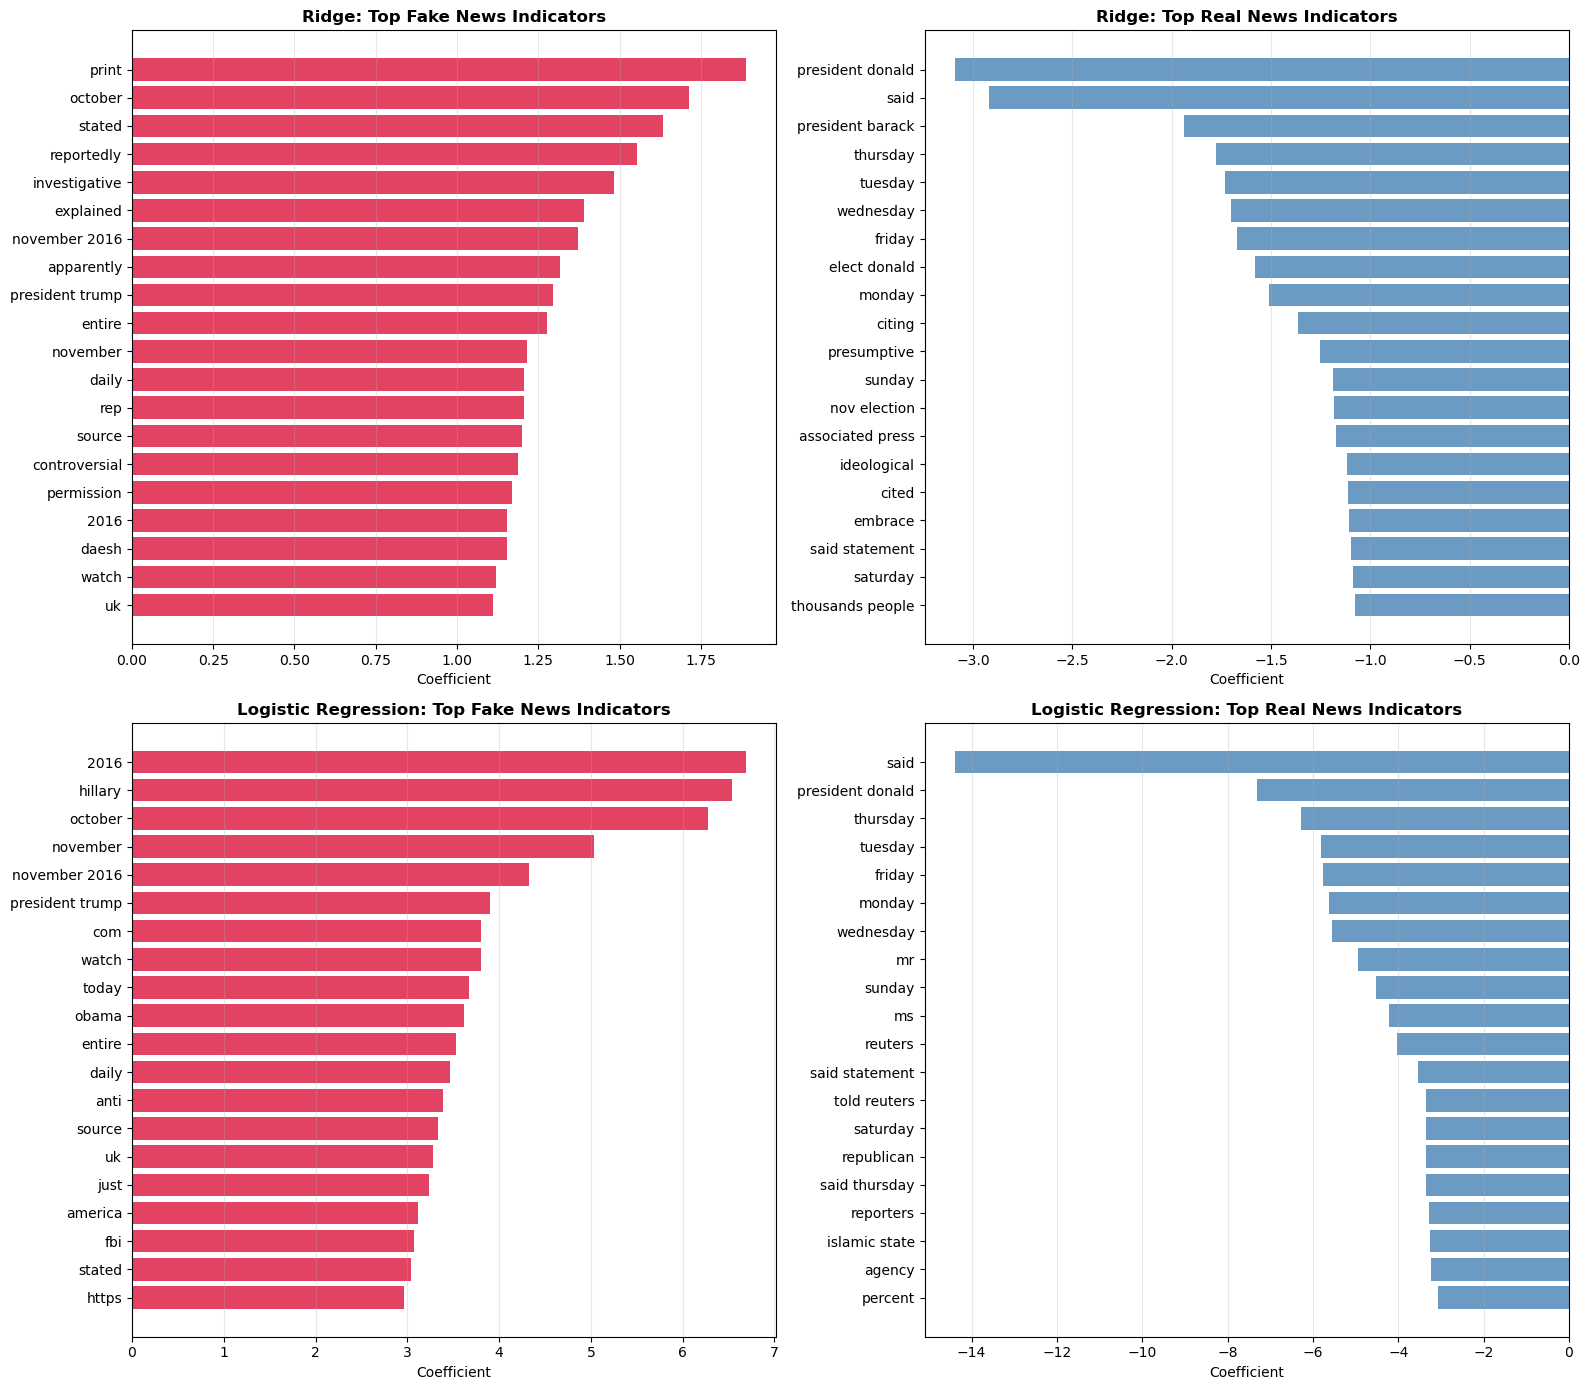

In [14]:
# Visual comparison of feature importance
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax, data, title, color in [
    (axes[0, 0], ridge_fake, 'Ridge: Top Fake News Indicators', 'crimson'),
    (axes[0, 1], ridge_real, 'Ridge: Top Real News Indicators', 'steelblue'),
    (axes[1, 0], lr_fake, 'Logistic Regression: Top Fake News Indicators', 'crimson'),
    (axes[1, 1], lr_real, 'Logistic Regression: Top Real News Indicators', 'steelblue'),
]:
    y_pos = np.arange(len(data))
    ax.barh(y_pos, data['coefficient'].values, color=color, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(data['feature'].values)
    ax.invert_yaxis()
    ax.set_xlabel('Coefficient')
    ax.set_title(title, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
# Feature overlap between models
ridge_fake_set = set(ridge_fake['feature'].values)
ridge_real_set = set(ridge_real['feature'].values)
lr_fake_set = set(lr_fake['feature'].values)
lr_real_set = set(lr_real['feature'].values)

fake_overlap = ridge_fake_set & lr_fake_set
real_overlap = ridge_real_set & lr_real_set

print("=" * 60)
print("FEATURE OVERLAP BETWEEN MODELS")
print("=" * 60)
print(f"\nFake News Indicators (both models agree): {len(fake_overlap)}/20")
print(sorted(fake_overlap))
print(f"\nReal News Indicators (both models agree): {len(real_overlap)}/20")
print(sorted(real_overlap))


FEATURE OVERLAP BETWEEN MODELS

Fake News Indicators (both models agree): 11/20
['2016', 'daily', 'entire', 'november', 'november 2016', 'october', 'president trump', 'source', 'stated', 'uk', 'watch']

Real News Indicators (both models agree): 10/20
['friday', 'monday', 'president donald', 'said', 'said statement', 'saturday', 'sunday', 'thursday', 'tuesday', 'wednesday']
